In [1]:
# Import TensorFlow library for deep learning
import tensorflow as tf

# Import Keras, the high-level API of TensorFlow
from tensorflow import keras

# Import Pandas for creating and manipulating DataFrames
import pandas as pd

# Import NumPy for numerical operations
import numpy as np

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

In [2]:
# Import train_test_split to divide the dataset into training and testing sets
from sklearn.model_selection import train_test_split

# Import StandardScaler for feature normalization
from sklearn.preprocessing import StandardScaler

# Import the built-in handwritten digits dataset from scikit-learn
from sklearn.datasets import load_digits

In [3]:
digits=load_digits()

In [4]:
df = pd.DataFrame(digits.data, columns=digits.feature_names)
print(df.shape)

(1797, 64)


In [5]:
# Display the first five rows of the dataset
df.head()

,pixel_0_0,pixel_0_1,pixel_0_2,pixel_0_3,pixel_0_4,pixel_0_5,pixel_0_6,pixel_0_7,pixel_1_0,pixel_1_1,...,pixel_6_6,pixel_6_7,pixel_7_0,pixel_7_1,pixel_7_2,pixel_7_3,pixel_7_4,pixel_7_5,pixel_7_6,pixel_7_7
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,...,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,...,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1797 entries, 0 to 1796
Data columns (total 64 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   pixel_0_0  1797 non-null   float64
 1   pixel_0_1  1797 non-null   float64
 2   pixel_0_2  1797 non-null   float64
 3   pixel_0_3  1797 non-null   float64
 4   pixel_0_4  1797 non-null   float64
 5   pixel_0_5  1797 non-null   float64
 6   pixel_0_6  1797 non-null   float64
 7   pixel_0_7  1797 non-null   float64
 8   pixel_1_0  1797 non-null   float64
 9   pixel_1_1  1797 non-null   float64
 10  pixel_1_2  1797 non-null   float64
 11  pixel_1_3  1797 non-null   float64
 12  pixel_1_4  1797 non-null   float64
 13  pixel_1_5  1797 non-null   float64
 14  pixel_1_6  1797 non-null   float64
 15  pixel_1_7  1797 non-null   float64
 16  pixel_2_0  1797 non-null   float64
 17  pixel_2_1  1797 non-null   float64
 18  pixel_2_2  1797 non-null   float64
 19  pixel_2_3  1797 non-null   float64
 20  pixel_2_

In [7]:
# sum() calculates the total number of missing values in each column
print(df.isnull().sum())

pixel_0_0    0
pixel_0_1    0
pixel_0_2    0
pixel_0_3    0
pixel_0_4    0
            ..
pixel_7_3    0
pixel_7_4    0
pixel_7_5    0
pixel_7_6    0
pixel_7_7    0
Length: 64, dtype: int64


In [8]:
X=digits.data
Y=digits.target

In [9]:
scaler=StandardScaler()
X=scaler.fit_transform(X)

In [10]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,Y,test_size=0.2,random_state=42
)

In [12]:
model=keras.Sequential([
    keras.layers.Dense(64,activation='relu',input_shape=(64,)),
    keras.layers.Dense(32,activation='relu'),
    keras.layers.Dense(16,activation='relu'),
    keras.layers.Dense(10,activation='softmax')
])

c:\Users\Prachi Jadhav\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [14]:
model.fit(X_train,Y_train,epochs=20)

Epoch 1/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 15s 19ms/step - accuracy: 0.2526 - loss: 2.0373
Epoch 2/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6395 - loss: 1.3361
Epoch 3/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8365 - loss: 0.7151
Epoch 4/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.9158 - loss: 0.3707
Epoch 5/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.9436 - loss: 0.2276
Epoch 6/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9659 - loss: 0.1511
Epoch 7/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - accuracy: 0.9833 - loss: 0.1113
Epoch 8/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9882 - loss: 0.0780
Epoch 9/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.9916 - loss: 0.0584
Epoch 10/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9937 - loss: 0.0453
Epoch 11/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.9951 - loss: 0.0354
Epoch 12/20
45/45 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy

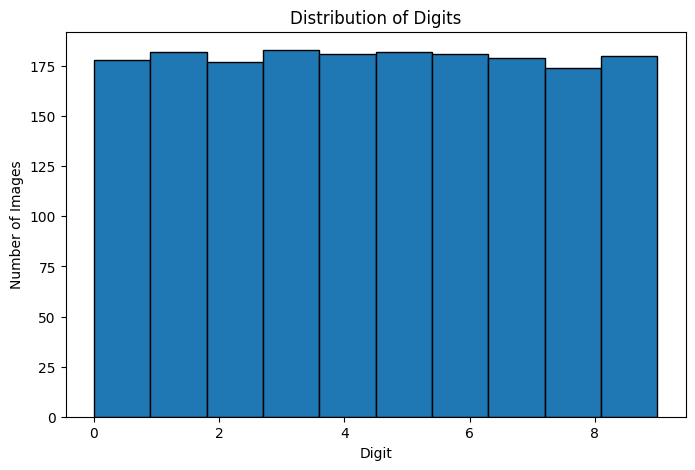

In [15]:
plt.figure(figsize=(8,5))
plt.hist(digits.target, bins=10, edgecolor='black')
plt.title("Distribution of Digits")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.show()

In [16]:
loss,accuracy=model.evaluate(X_test,Y_test)
print("Loss:",loss)
print("Accuracy:",accuracy)


12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 57ms/step - accuracy: 0.9722 - loss: 0.1006
Loss: 0.10057539492845535
Accuracy: 0.9722222089767456
